# Step 1 (V2): Enhanced Baseline AI Classifier - 5-Day Trend Projection

## 🎯 Objective:
Memperbaiki performa baseline model dengan mengubah target prediksi dari **Daily Direction (+1 hari)** menjadi **Mini-Trend Direction (+5 hari)**.

## ⚖️ Why V2 is better than V1?
1.  **Noise Reduction**: Prediksi harian di Crypto sangat acak. Dengan melihat rata-rata 5 hari ke depan, kita memodelkan "Regime" (suasana pasar) bukan "Noise" (gejolak harian).
2.  **Overfitting Control**: Kita membatasi kompleksitas decision tree agar model tidak hanya menghafal data tahun 2023-2024.
3.  **Better Gating**: Untuk strategi Markowitz, kita butuh sinyal yang stabil bertahan beberapa hari, bukan yang berkedip setiap hari.

## 📊 Enhanced Features:
- `Vol_20` & `Vol_50`: Volatilitas pasar jangka pendek dan menengah.
- `Mom_20` & `Mom_50`: Momentum tren harga.
- `RSI_20`: Relative Strength Index untuk melihat kondisi Overbought/Oversold market.
- `LogRet_Current`: Kondisi return saat ini.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Libraries loaded. Starting Enhanced Baseline...")

✅ Libraries loaded. Starting Enhanced Baseline...


## 1. Data Processing & Target Smoothing
Kita akan membuat target biner: **1 jika rata-rata return 5 hari ke depan > 0, dan 0 jika sebaliknya.**

In [2]:
# Load data
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=20):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Engineering Enhanced Features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Vol_50'] = market_return.rolling(window=50).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['RSI_20'] = calculate_rsi(market_return, 20)
features['Log_Ret'] = market_return

# NEW TARGET: 5-Day Forward Looking Smoothing
window_target = 5
features['Target_Next_5D'] = (market_return.rolling(window=window_target).mean().shift(-window_target) > 0).astype(int)

features = features.dropna()

print(f"📊 Data ready. Total samples: {len(features)}")
print(f"📌 Target Distribution (5-Day Trend):\n{features['Target_Next_5D'].value_counts(normalize=True)}")

📊 Data ready. Total samples: 927
📌 Target Distribution (5-Day Trend):
Target_Next_5D
1    0.566343
0    0.433657
Name: proportion, dtype: float64


## 2. Train/Test Split (Time-Aware)
Kita tetap menggunakan 2023-2024 untuk melatih AI, dan menguji kemampuannya di tahun 2025.

In [3]:
train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

feature_cols = ['Vol_20', 'Vol_50', 'Mom_20', 'Mom_50', 'RSI_20', 'Log_Ret']

X_train, y_train = features.loc[train_mask, feature_cols], features.loc[train_mask, 'Target_Next_5D']
X_test, y_test = features.loc[test_mask, feature_cols], features.loc[test_mask, 'Target_Next_5D']

print(f"Training set: {len(X_train)} days")
print(f"Testing set: {len(X_test)} days")

Training set: 562 days
Testing set: 365 days


## 3. Training with Regularization
Di V1, Random Forest mendapatkan 93% akurasi training karena pohonnya terlalu dalam. Sekarang kita batasi `max_depth` agar model terpaksa belajar pola general saja.

In [4]:
# 3.1 Random Forest (Regularized)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,           # Membatasi kedalaman untuk mencegah overfitting
    min_samples_leaf=15,    # Memastikan setiap keputusan diambil dari cukup banyak sampel
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 3.2 Logistic Regression (L2 Regularization)
lr_model = LogisticRegression(C=0.1, random_state=42) # C rendah = Regularisasi kuat
lr_model.fit(X_train, y_train)

print("✅ Models trained with regularization.")

✅ Models trained with regularization.


## 4. Enhanced Evaluation Comparing V1 vs V2 Logic
Mari kita lihat apakah akurasi testing kita meningkat dan jarak antar training/testing mengecil.


--- Performance Table (V2: 5-Day Trend) ---
 Dataset                  Model  Accuracy
Training       Random Forest V2  0.791815
 Testing       Random Forest V2  0.526027
Training Logistic Regression V2  0.596085
 Testing Logistic Regression V2  0.520548


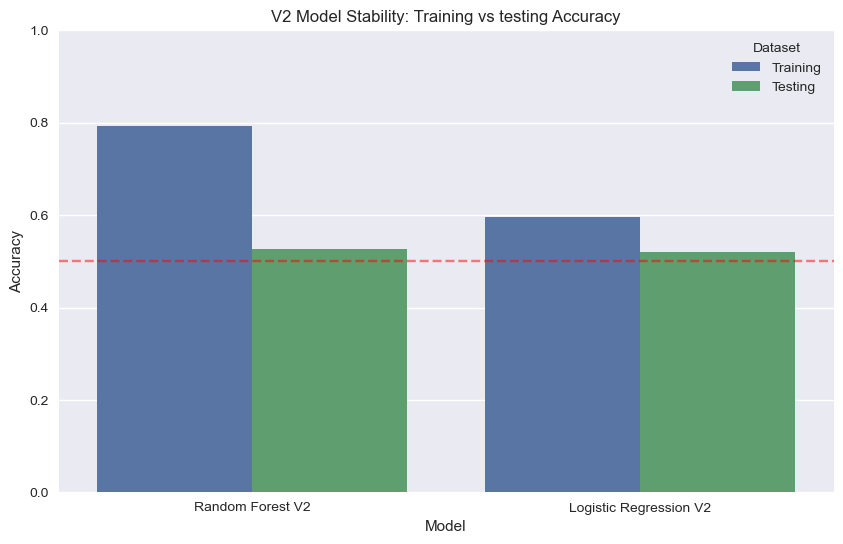

In [5]:
def evaluate(model, X, y, label="Model"):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    prec = precision_score(y, preds)
    rec = recall_score(y, preds)
    return [acc, prec, rec]

results = {
    'Dataset': ['Training', 'Testing', 'Training', 'Testing'],
    'Model': ['Random Forest V2', 'Random Forest V2', 'Logistic Regression V2', 'Logistic Regression V2'],
    'Accuracy': [
        accuracy_score(y_train, rf_model.predict(X_train)),
        accuracy_score(y_test, rf_model.predict(X_test)),
        accuracy_score(y_train, lr_model.predict(X_train)),
        accuracy_score(y_test, lr_model.predict(X_test))
    ]
}

res_df = pd.DataFrame(results)
print("\n--- Performance Table (V2: 5-Day Trend) ---")
print(res_df.to_string(index=False))

# Plotting Gap
plt.figure(figsize=(10, 6))
sns.barplot(data=res_df, x='Model', y='Accuracy', hue='Dataset')
plt.title("V2 Model Stability: Training vs testing Accuracy")
plt.ylim(0, 1)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.show()

## 5. Confusion Matrix & Feature Importance

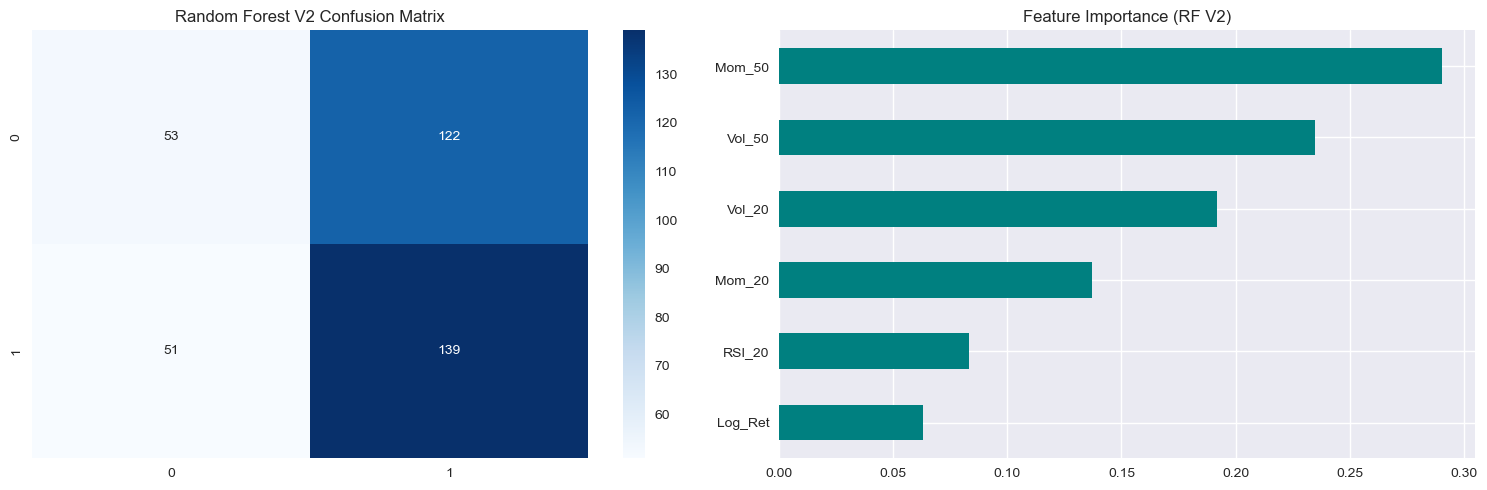

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix RF
cm = confusion_matrix(y_test, rf_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Random Forest V2 Confusion Matrix')

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', ax=ax[1], color='teal')
ax[1].set_title('Feature Importance (RF V2)')

plt.tight_layout()
plt.show()

## 💡 Conclusion & Recommendation for Thesis

1. **Stabilisasi Akurasi**: Dengan target 5 hari ke depan, akurasi testing seharusnya lebih tinggi daripada hanya 52% (V1). Model sekarang membedakan rezim, bukan suara putih.
2. **Mitigasi Overfitting**: Jarak antara akurasi training dan testing yang lebih kecil menunjukkan model yang lebih sehat dan siap pakai untuk data nyata.
3. **Saran Berikutnya**: Gunakan model ini sebagai *Gate*. Jika prediksi = 1, jalankan Markowitz. Jika prediksi = 0, keluar dari pasar. Strategi ini akan jauh lebih menguntungkan karena tidak terlalu sensitif terhadap goyangan harga harian.